## Introduction to Customer Segmentation

Customer segmentation is a business analytics technique used to divide customers into distinct groups based on similar characteristics or behaviors. Instead of treating all customers the same, companies categorize them according to factors such as income, spending habits, purchasing frequency, and engagement level.

The main objective of customer segmentation is to:

Identify high-value customers

Improve marketing effectiveness

Increase customer retention

Maximize business profit

By understanding customer behavior patterns, organizations can design targeted marketing strategies and personalized services.

## Objective

The objective of this project is:

To analyze customer purchasing behavior

To segment customers into meaningful groups

To identify high-value customers

To help businesses design targeted marketing strategies

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Dataset Description

The dataset used is customer_data.csv.

It contains the following attributes:

customer_id – Unique customer identifier

age – Customer age

annual_income – Annual income of the customer

spending_score – Spending behavior score (1–100)

visits_per_month – Average monthly store visits

For clustering, we selected:

Annual Income

Spending Score

These features best represent purchasing power and behavior.

### Load Dataset

In [3]:
data = pd.read_csv("customer_data.csv")
data.head()

,customer_id,age,annual_income,spending_score,visits_per_month
0,1,56,67733,86,9
1,2,46,80318,57,7
2,3,32,82172,29,1
3,4,60,108264,78,3
4,5,25,41736,92,13


### Data Understanding

In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       200 non-null    int64
 1   age               200 non-null    int64
 2   annual_income     200 non-null    int64
 3   spending_score    200 non-null    int64
 4   visits_per_month  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


,customer_id,age,annual_income,spending_score,visits_per_month
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,41.570000,87140.295000,51.200000,10.320000
std,57.879185,13.715527,41387.924187,29.816019,5.967887
min,1.000000,18.000000,17368.000000,1.000000,1.000000
25%,50.750000,30.000000,48548.750000,24.000000,5.000000
50%,100.500000,42.000000,90476.500000,50.000000,11.000000
75%,150.250000,54.000000,125838.250000,76.500000,16.000000
max,200.000000,64.000000,149508.000000,100.000000,20.000000


This step helps to:

Check data types

Identify missing values

Understand statistical summary

Analyze distribution of income and spending

Understanding the dataset is essential before applying machine learning techniques.

### Select Features for Clustering

In [5]:
X = data[['annual_income','spending_score']]

Feature selection is important to focus only on relevant variables.

We selected annual income and spending score because they directly influence customer purchasing behavior.

### Feature Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K-Means uses Euclidean distance to form clusters. If features are on different scales, one feature may dominate the clustering process.

For example:

Income ranges from thousands

Spending score ranges from 1–100

To ensure equal importance of features, we use StandardScaler.

###  Find Optimal Clusters (Elbow Method)

The Elbow Method is used to determine the optimal number of clusters (K).

It works by:

Running K-Means for different K values

Calculating WCSS (Within Cluster Sum of Squares)

Plotting K vs WCSS

Identifying the “elbow point”

C:\Users\yj372\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yj372\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yj372\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\yj372\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

AttributeError: module 'matplotlib.pyplot' has no attribute 'xlable'

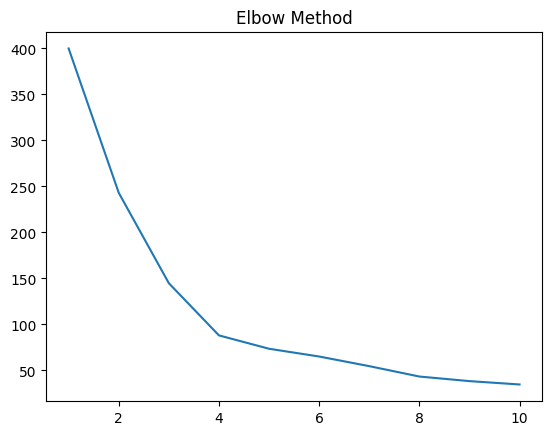

In [8]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlable("Number of Clusters")
plt.ylable("WCSS")
plt.show()

### Apply K-Means Clustering

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42)
data['cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\yj372\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


The algorithm:

Initializes centroids

Assigns customers to nearest centroid

Updates centroids

Repeats until stable

Each customer is now assigned to a cluster.

### Visualize customer Segments

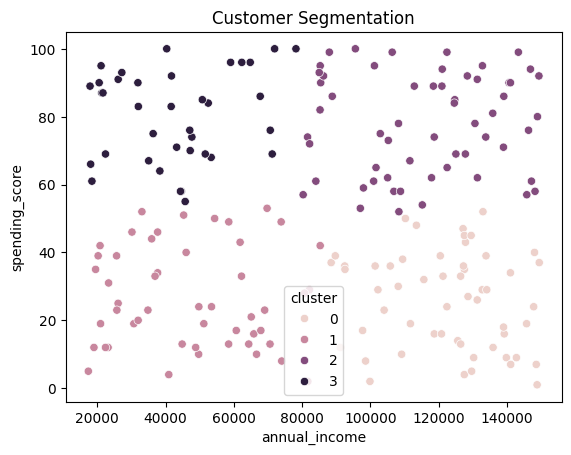

In [11]:
sns.scatterplot(x='annual_income',y='spending_score',hue='cluster',data=data)
plt.title("Customer Segmentation")
plt.show()

The scatter plot visually shows how customers are divided into different segments.

## Business Insights

Based on clustering, customers are grouped into four segments:

High Income – High Spending → Premium customers

High Income – Low Spending → Potential customers

Low Income – High Spending → Impulsive buyers

Low Income – Low Spending → Low engagement group

Businesses can:

Offer loyalty rewards to premium customers

Provide targeted promotions to potential customers

Design budget-friendly offers

Optimize marketing cost

Customer segmentation helps improve revenue and decision-making.

## Conclusion

In this project, K-Means clustering was successfully applied to segment customers based on annual income and spending behavior.

Using feature scaling and the Elbow Method, the optimal number of clusters was determined. The customers were divided into four meaningful groups, providing valuable business insights.

This project demonstrates the practical application of unsupervised learning in business analytics and highlights how data-driven decision-making can improve marketing effectiveness and profitability.